#### Librerias

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

Mounted at /content/drive


#### Variables

In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/Trabajo práctico 3/data/training.1600000.processed.noemoticon.csv"
TEST_PATH = "/content/drive/MyDrive/Trabajo práctico 3/data/testdata.manual.2009.06.14.csv"
cols = ['polarity', 'id', 'date', 'query', 'user', 'text']

#### Lectura de datos

In [ ]:
df_train = pd.read_csv(TRAIN_PATH, encoding='latin-1', header=None, names=cols)
df_test = pd.read_csv(TEST_PATH, encoding='latin-1', header=None, names=cols)

In [ ]:
df_train.shape, df_test.shape

((1600000, 6), (498, 6))

In [ ]:
df_train.head()

,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df_train.sample(5, random_state=42)

,polarity,id,date,query,user,text
541200,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!
750,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo..."
766711,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...
285055,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...
705995,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   polarity  1600000 non-null  int64 
 1   id        1600000 non-null  int64 
 2   date      1600000 non-null  object
 3   query     1600000 non-null  object
 4   user      1600000 non-null  object
 5   text      1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [ ]:
df_train.isna().sum()

,0
polarity,0
id,0
date,0
query,0
user,0
text,0


In [ ]:
print("Duplicados en train:", df_train.duplicated(subset="text").sum())
print("Duplicados en test:", df_test.duplicated(subset="text").sum())

Duplicados en train: 18534
Duplicados en test: 0


No hay valores nulos en ninguna columna. En train hay 18.534 tweets con texto
duplicado (~1,2% del total), algo esperable en Twitter (retweets, frases repetidas
tipo "good morning"). Se decidió no eliminarlos: representan mensajes reales que
efectivamente se publicaron, y con ese volumen no distorsionan el balance de
clases. El test no tiene duplicados.

#### Balance de clases

In [ ]:
df_train.polarity.value_counts(normalize=True) * 100

,proportion
polarity,
0,50.0
4,50.0


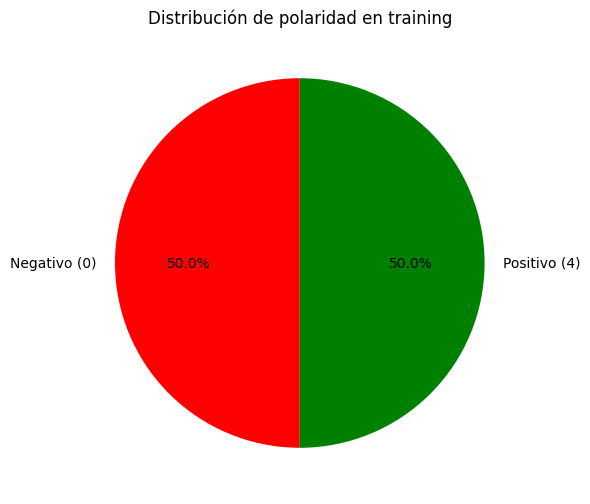

In [ ]:
plt.figure(figsize=(6,6))
conteo = df_train.polarity.value_counts()
plt.pie(conteo, labels=["Negativo (0)", "Positivo (4)"], autopct="%1.1f%%", startangle=90, colors=["red", "green"])
plt.title("Distribución de polaridad en training")
plt.show()

El training está perfectamente balanceado: 50% negativos y 50% positivos, 800 mil
de cada uno. Esto simplifica todo lo que viene después: no hace falta aplicar
técnicas de balanceo y el accuracy es una métrica confiable (con clases
desbalanceadas sería engañosa). Llama la atención que no hay ningún tweet neutral
(clase 2) en el training.

In [ ]:
df_test.polarity.value_counts(normalize=True) * 100

,proportion
polarity,
4,36.546185
0,35.542169
2,27.911647


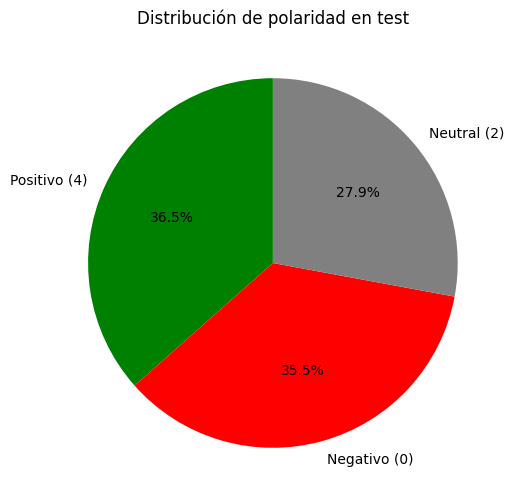

In [ ]:
plt.figure(figsize=(6,6))
conteo_test = df_test.polarity.value_counts()
plt.pie(conteo_test, labels=["Positivo (4)", "Negativo (0)", "Neutral (2)"], autopct="%1.1f%%", startangle=90, colors=["green", "red", "gray"])
plt.title("Distribución de polaridad en test")
plt.show()

El test sí tiene las tres clases: 177 negativos, 139 neutrales y 182 positivos.
Acá aparece el problema central del proyecto: el modelo se va a entrenar solo con
positivos y negativos, pero el test real incluye una clase que nunca va a ver.
Esta decisión se retoma en la notebook 03, donde se define evaluar sobre el
subset binario del test.

#### Longitud de tweets

In [ ]:
df_train["longitud"] = df_train["text"].str.len()

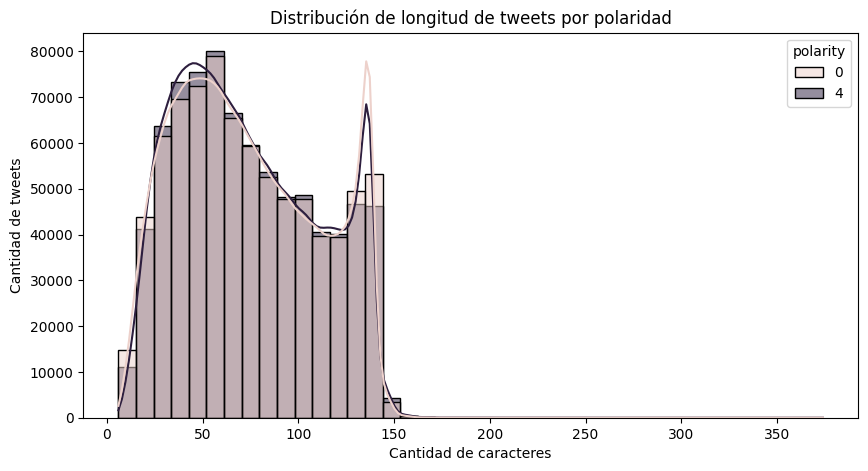

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_train, x="longitud", hue="polarity", kde=True, bins=40)
plt.title("Distribución de longitud de tweets por polaridad")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Cantidad de tweets")
plt.show()

In [ ]:
df_train.groupby("polarity")["longitud"].describe()

,count,mean,std,min,25%,50%,75%,max
polarity,,,,,,,,
0,800000.0,74.301790,36.743260,6.0,44.0,70.0,104.0,359.0
4,800000.0,73.878433,36.135274,6.0,44.0,69.0,103.0,374.0


Los tweets son cortos: mediana de 69 caracteres, con un máximo de 374. La
distribución de longitud es muy parecida entre positivos y negativos, así que la
longitud por sí sola no sirve para distinguir sentimiento. El dato de la mediana
importa para después: con textos tan cortos, cada palabra pesa mucho en la
representación vectorial.

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def palabras_simples(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|@\w+|[^a-z\s]', '', texto)
    return [t for t in texto.split() if t not in stop_words and len(t) > 2]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from collections import Counter

muestra_neg = df_train[df_train.polarity == 0].text.sample(50000, random_state=42)
muestra_pos = df_train[df_train.polarity == 4].text.sample(50000, random_state=42)

palabras_neg = Counter([w for t in muestra_neg for w in palabras_simples(t)])
palabras_pos = Counter([w for t in muestra_pos for w in palabras_simples(t)])

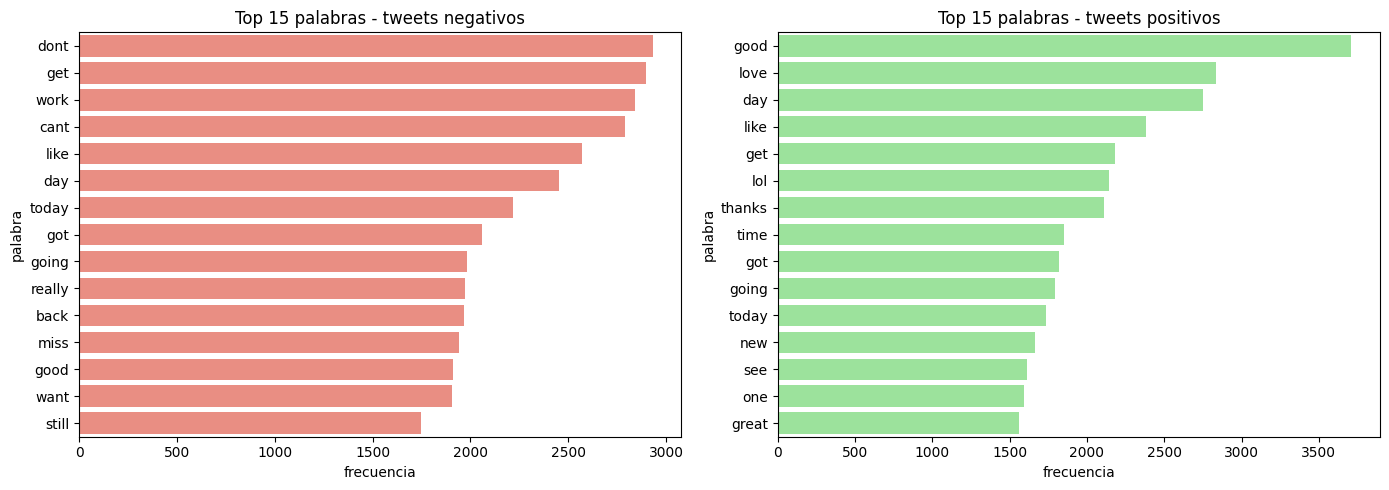

In [ ]:
top_neg = pd.DataFrame(palabras_neg.most_common(15), columns=["palabra", "frecuencia"])
top_pos = pd.DataFrame(palabras_pos.most_common(15), columns=["palabra", "frecuencia"])

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(data=top_neg, x="frecuencia", y="palabra", ax=axes[0], color="salmon")
axes[0].set_title("Top 15 palabras - tweets negativos")
sns.barplot(data=top_pos, x="frecuencia", y="palabra", ax=axes[1], color="lightgreen")
axes[1].set_title("Top 15 palabras - tweets positivos")
plt.tight_layout()
plt.show()

Las palabras más frecuentes de cada clase tienen sentido: en los negativos aparecen
términos como "work", "cant", "dont", y en los positivos "good", "love", "thanks".
Hay palabras que aparecen en ambos lados ("day", "today", "get") — son frecuentes
pero poco informativas para distinguir sentimiento. Esto anticipa lo que los
modelos van a aprovechar: las palabras con carga emocional clara son las que
separan las clases.

#### Temas en el set de test

In [ ]:
df_test["query"].value_counts().head(15)

,count
query,
time warner,35
"""night at the museum""",25
nike,25
gm,22
kindle2,20
safeway,20
lebron,18
dentist,17
jquery,16


El test se armó buscando tweets por tema (kindle2, obama, twitter, etc. — 81 temas
distintos), mientras que el training es genérico (todo NO_QUERY). Es una diferencia
de origen entre los dos datasets que conviene tener presente: el test no es una
muestra aleatoria del mismo universo que el training.